# Analog Holidays - 38h Offset Forecast

Thin orchestration notebook for running `AnalogSpecialDays` from the hourly wide holiday audit CSV.

This variant forecasts a 38-hour window that starts 14 hours before the holiday midnight, so the operational forecast is ready before the holiday begins.

The loading, normalization, forecasting, and plotting logic lives in `analog/analog_holidays.py`. This notebook only defines parameters and calls the plotting helpers.

The CSV export only preserves holiday flags, so this workflow targets holiday analogs and can optionally restrict the analog bank to the same selector `analog_cluster`.

In [10]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import analog_holidays.analog.analog_special_days as analog_special_days_module
import analog_holidays.analog.analog_holidays as analog_holidays_module

analog_special_days_module = importlib.reload(analog_special_days_module)
analog_holidays_module = importlib.reload(analog_holidays_module)

from analog_holidays.analog.analog_holidays import (
    build_analog_ranking_table,
    build_run_summary,
    plot_analog_pair_sequences,
    plot_batch_inference_grid,
    plot_batch_pair_sequences_grid,
    plot_forecast_diagnostics,
    plot_ranked_analog_profiles,
    prepare_audit_working_copy,
    run_analog_holidays,
    run_analog_holidays_batch,
    tune_analog_holidays_optuna,
)

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)

## Parameters

Adjust the series, target date, and analog hyperparameters for the holiday-only CSV source.

- SOURCE_PATH: path to the holiday CSV file consumed by the notebook.
- UNIQUE_ID: target series used to build analogs and generate the forecast.
- TARGET_DATE: holiday date whose operational forecast window should be estimated.
- FORECAST_START_OFFSET_HOURS: how many hours before the holiday midnight the forecast window starts.
- SEASON_LENGTH: hourly profile length to model, in hours. For this workflow it should match `FORECAST_START_OFFSET_HOURS + 24`.
- SPECIAL_LABELS: labels that define which days are treated as special candidates when selecting analogs.
- K: number of special neighbors kept after ranking X against Y by similarity; None uses every filtered candidate.
- TYPEDIST: metric used to rank holiday candidates against Y; supports pearson, euclidian, and dtw.
- TYPEREG: regressor type used in the analog reconstruction step.
- N_COMPONENTS: number of components for dimensionality-reduction methods such as PCR or PLS.
- LEVELS: prediction interval levels to compute for the forecast.
- MIN_SPECIAL_POINTS: minimum number of hours flagged as special inside a candidate block.
- MIN_EVENT_GAP: minimum separation between consecutive special events to avoid overly overlapping candidates.
- MAX_EVENTS: maximum number of special events used as the analog bank; None uses all available events.
- SELECTOR_FEATURES_PATH / CLUSTER_COLUMN / MATCH_TARGET_CLUSTER: optional selector-cluster filter for keeping only analogs in the same `analog_cluster` as the target holiday.
- MAX_PLOTTED_ANALOGS: maximum number of analogs shown in the comparative plots.

In [11]:
import shutil
from datetime import datetime

# Original CSV — never modified by this notebook.
_ORIGINAL_SOURCE = PROJECT_ROOT / 'analog_holidays' / 'holidays' / 'holiday_demand_mx.csv'

# Create a fresh timestamped working copy on every notebook launch.
_timestamp = datetime.now().strftime('%Y_%m_%d_%H_%M')
SOURCE_PATH = _ORIGINAL_SOURCE.with_name(f'holiday_demand_mx_{_timestamp}.csv')
shutil.copy2(_ORIGINAL_SOURCE, SOURCE_PATH)
print(f'Working copy: {SOURCE_PATH.name}')

UNIQUE_ID = 'SEN_demand_CEL'
UNIQUE_ID = 'SEN_demand_PEN'
UNIQUE_ID = 'SEN_demand_SIN'

Working copy: holiday_demand_mx_2026_05_25_09_41.csv


In [12]:
SPECIAL_LABELS = ('holiday',)
FORECAST_START_OFFSET_HOURS = 14
SEASON_LENGTH = 38  # 14 h pre-holiday + 24 h holiday
K = 1000
TYPEDIST = 'pearson'
TYPEREG = 'PCR'
N_COMPONENTS = 3
LEVELS = [80, 95]
MIN_SPECIAL_POINTS = 24  # require the 24 holiday hours inside each 38-h candidate window
MIN_EVENT_GAP = 24
MAX_EVENTS = None
MAX_PLOTTED_ANALOGS = 10

SELECTOR_FEATURES_PATH = PROJECT_ROOT / 'analog_holidays' / 'holidays' / 'holiday_selector_features.csv'
CLUSTER_COLUMN = 'analog_cluster'
MATCH_TARGET_CLUSTER = True

DATE_END = '2024-01-01'  # only dates strictly earlier than this cutoff are included in the study
OPTUNA_N_TRIALS = 25
OPTUNA_TIMEOUT_SEC = 900
OPTUNA_MAX_EVAL_DATES = 12
OPTUNA_RANDOM_SEED = 42

In [13]:
# TARGET_DATES_2025 = [
#     ('2024-01-01', "New Year's Day"),
#     ('2024-02-05', 'Constitution Day'),
#     ('2024-03-18', "Benito Juarez's Birthday"),
#     ('2024-03-28', 'Maundy Thursday'),
#     ('2024-03-29', 'Good Friday'),
#     ('2024-03-30', 'Holy Saturday'),
#     ('2024-05-01', 'Labor Day'),
#     ('2024-09-15', 'Independence Eve'),
#     ('2024-10-01', 'Presidential Inauguration'),
#     ('2024-11-02', 'Day of the Dead'),
#     ('2024-11-18', 'Mexican Revolution Day'),
#     ('2024-12-24', 'Christmas Eve'),
#     ('2024-12-25', 'Christmas Day'),
#     ('2024-12-31', "New Year's Eve"),
      # ===== 2025 =====
TARGET_DATES_2025 = [
    ('2025-01-01', "New Year's Day"),
    ('2025-02-03', 'Constitution Day'),
    ('2025-03-17', "Benito Juarez's Birthday"),
    ('2025-04-17', 'Maundy Thursday'),
    ('2025-04-18', 'Good Friday'),
    ('2025-04-19', 'Holy Saturday'),
    ('2025-05-01', 'Labor Day'),
    ('2025-09-16', 'Independence Day'),
    ('2025-11-17', 'Mexican Revolution Day'),
    ('2025-12-24', 'Christmas Eve'),
    ('2025-12-25', 'Christmas Day'),
    ('2025-12-31', "New Year's Eve"),
    # ===== 2026 =====
    ('2026-01-01', "New Year's Day"),    
    ('2026-02-02', 'Constitution Day'),
    ('2026-03-16', "Benito Juarez's Birthday"),
    ('2026-04-02', 'Maundy Thursday'),
    ('2026-04-03', 'Good Friday'),
    ('2026-04-04', 'Holy Saturday'),
    ('2026-05-01', 'Labor Day'),
    # ('2026-09-15', 'Independence Eve'),
    # ('2026-09-16', 'Independence Day'),
    # ('2026-11-16', 'Mexican Revolution Day'),
    # ('2026-12-24', 'Christmas Eve'),
    # ('2026-12-25', 'Christmas Day'),
    # ('2026-12-31', "New Year's Eve"),
]

TARGET_DATE = TARGET_DATES_2025[-1][0]

In [14]:
optuna_result = tune_analog_holidays_optuna(
    unique_id=UNIQUE_ID,
    source_path=SOURCE_PATH,
    train_end=DATE_END,
    season_length=SEASON_LENGTH,
    forecast_start_offset_hours=FORECAST_START_OFFSET_HOURS,
    initial_k=K,
    initial_typedist=TYPEDIST,
    initial_typereg=TYPEREG,
    initial_n_components=N_COMPONENTS,
    n_trials=OPTUNA_N_TRIALS,
    timeout_sec=OPTUNA_TIMEOUT_SEC,
    max_eval_dates=OPTUNA_MAX_EVAL_DATES,
    random_seed=OPTUNA_RANDOM_SEED,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
    selector_features_path=SELECTOR_FEATURES_PATH,
    cluster_column=CLUSTER_COLUMN,
    match_target_cluster=MATCH_TARGET_CLUSTER,
 )

K = int(optuna_result.best_config['k'])
TYPEDIST = optuna_result.best_config['typedist']
TYPEREG = optuna_result.best_config['typereg']
N_COMPONENTS = int(optuna_result.best_config['n_components'])

print('Hyperparameters updated for the next notebook run.')
display(optuna_result.summary_df)
optuna_result.fold_metrics_df

Hyperparameters updated for the next notebook run.


,param,value
0,cutoff_train,2024-01-01
1,eval_dates,12
2,FORECAST_START_OFFSET_HOURS,14
3,best_mean_mae,983.697555
4,best_mean_mape_pct,3.268
5,best_fail_rate,0.0
6,K,5
7,TYPEDIST,pearson
8,TYPEREG,PCR
9,N_COMPONENTS,3


,target_date,mae,mape_pct,selected_analogs,fail,train_days,train_special_days
0,2023-02-06,549.853719,1.920585,5,False,764,15
1,2023-03-20,502.296576,1.666650,5,False,806,16
2,2023-04-06,765.951458,2.141080,4,False,823,4
3,2023-04-07,1391.603055,4.523194,5,False,824,17
4,2023-04-08,819.840018,2.699567,5,False,825,18
5,2023-04-09,701.725386,2.361980,5,False,826,19
6,2023-05-01,952.043569,2.834875,5,False,848,20
7,2023-09-16,1895.308990,5.095748,5,False,986,5
8,2023-11-20,497.910217,1.666732,5,False,1051,21
9,2023-12-24,1041.782553,3.752453,5,False,1085,22


In [15]:
batch_result_2025 = run_analog_holidays_batch(
    target_dates=TARGET_DATES_2025,
    unique_id=UNIQUE_ID,
    source_path=SOURCE_PATH,
    season_length=SEASON_LENGTH,
    forecast_start_offset_hours=FORECAST_START_OFFSET_HOURS,
    k=K,
    typedist=TYPEDIST,
    typereg=TYPEREG,
    n_components=N_COMPONENTS,
    levels=LEVELS,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
    expected_target_label=None,
    selector_features_path=SELECTOR_FEATURES_PATH,
    cluster_column=CLUSTER_COLUMN,
    match_target_cluster=MATCH_TARGET_CLUSTER,
 )

display(batch_result_2025.results_df)
batch_result_2025.metric_summary_df

,target_date,holiday_label,forecast_start,forecast_end,forecast_start_offset_hours,forecast_hours,target_exists,target_has_complete_profile,selected_analogs,fail,...,mape_window_pct,mae_24h,mape_24h_pct,t_sel_sec,t_reg_sec,k,typedist,typereg,n_components,error
0,2025-01-01,New Year's Day,2024-12-31 10:00:00,2025-01-02,14,38,True,True,5,False,...,1.781745,459.329991,1.781745,0.002991,0.002993,5,pearson,PCR,3,None
1,2025-02-03,Constitution Day,2025-02-02 10:00:00,2025-02-04,14,38,True,True,5,False,...,1.349229,399.146542,1.349229,0.003997,0.003036,5,pearson,PCR,3,None
2,2025-03-17,Benito Juarez's Birthday,2025-03-16 10:00:00,2025-03-18,14,38,True,True,5,False,...,3.133822,946.500479,3.133822,0.003738,0.002846,5,pearson,PCR,3,None
3,2025-04-17,Maundy Thursday,2025-04-16 10:00:00,2025-04-18,14,38,True,True,5,False,...,6.749951,2558.606330,6.749951,0.004987,0.003204,5,pearson,PCR,3,None
4,2025-04-18,Good Friday,2025-04-17 10:00:00,2025-04-19,14,38,True,True,5,False,...,2.154092,748.543157,2.154092,0.003588,0.002975,5,pearson,PCR,3,None
5,2025-04-19,Holy Saturday,2025-04-18 10:00:00,2025-04-20,14,38,True,True,5,False,...,7.208429,2399.616181,7.208429,0.004338,0.002132,5,pearson,PCR,3,None
6,2025-05-01,Labor Day,2025-04-30 10:00:00,2025-05-02,14,38,True,True,5,False,...,1.960471,779.829221,1.960471,0.008585,0.005489,5,pearson,PCR,3,None
7,2025-09-16,Independence Day,2025-09-15 10:00:00,2025-09-17,14,38,True,True,5,False,...,6.475305,2344.958066,6.475305,0.011325,0.007831,5,pearson,PCR,3,None
8,2025-11-17,Mexican Revolution Day,2025-11-16 10:00:00,2025-11-18,14,38,True,True,5,False,...,1.995047,660.495615,1.995047,0.004043,0.001957,5,pearson,PCR,3,None
9,2025-12-24,Christmas Eve,2025-12-23 10:00:00,2025-12-25,14,38,True,True,5,False,...,6.968057,2180.801744,6.968057,0.004986,0.002111,5,pearson,PCR,3,None


,mae_window,mape_window_pct
count,19.000000,19.000000
mean,1337.939877,4.058660
std,799.370247,2.360875
min,399.146542,1.349229
25%,712.940777,2.024023
50%,946.500479,3.133822
75%,2102.681339,6.396410
max,2618.565131,8.812266


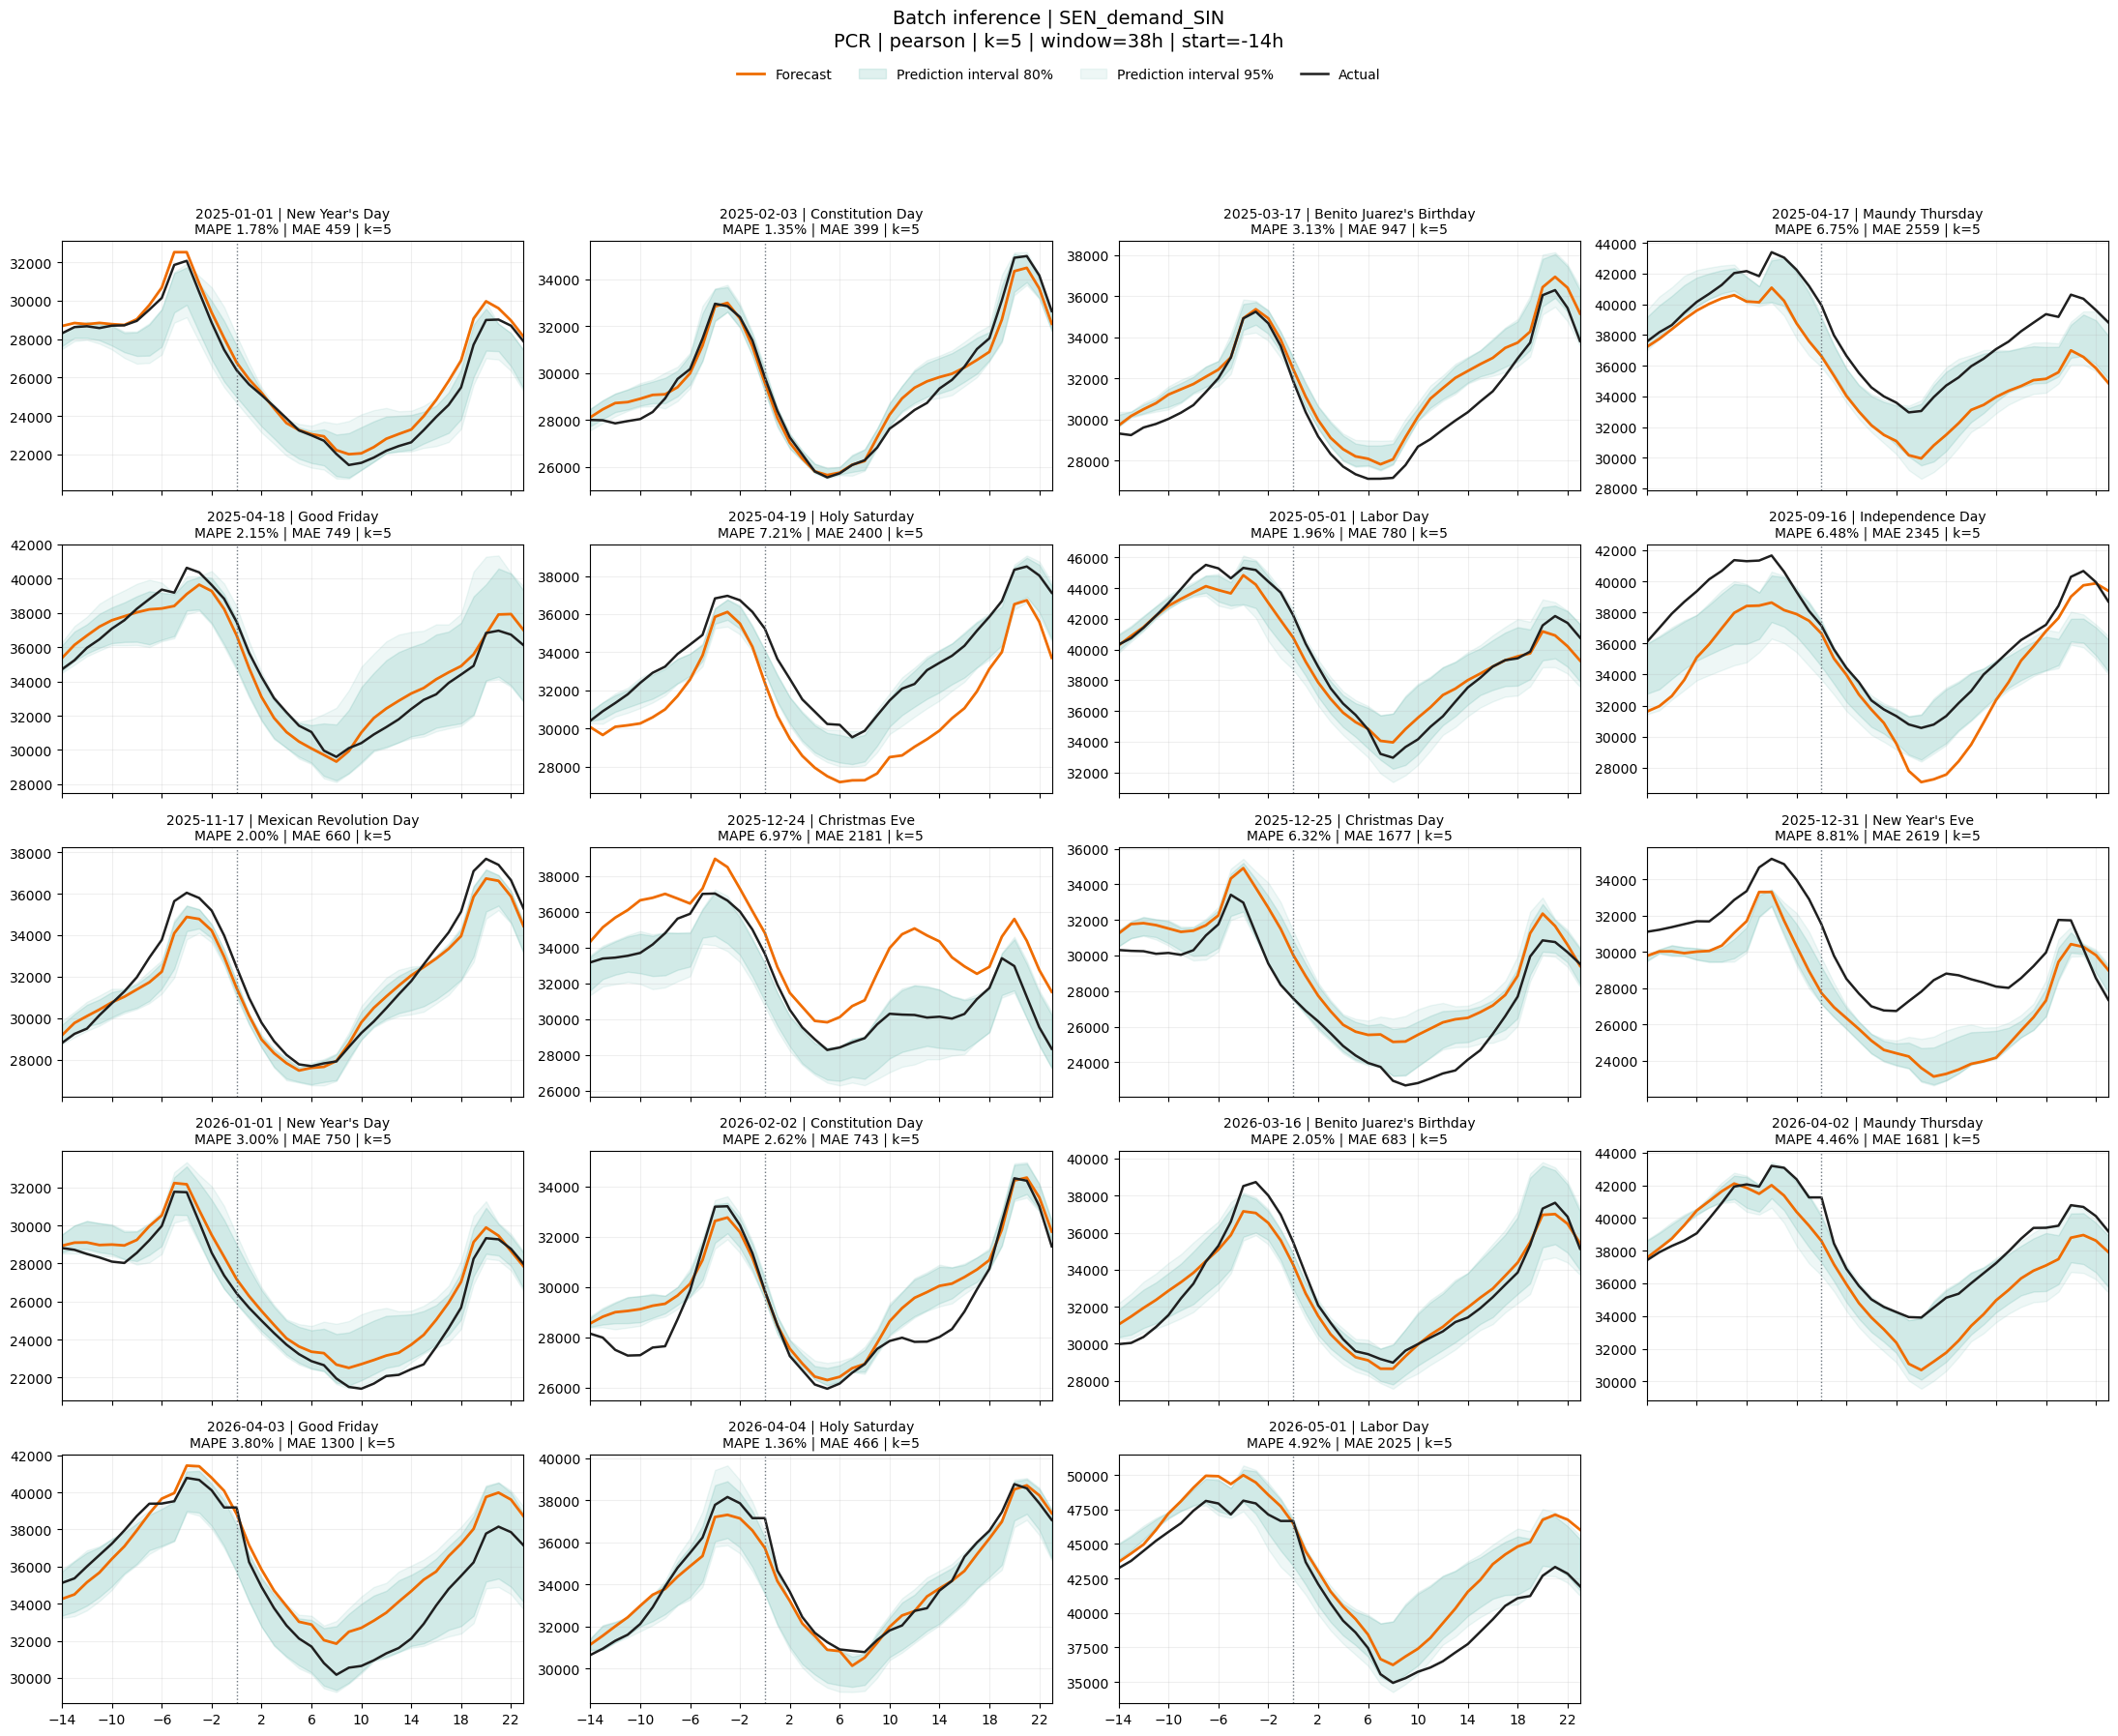

In [16]:
fig, axes = plot_batch_inference_grid(
    batch_result_2025,
    title=(
        f'Batch inference | {UNIQUE_ID}\n'
        f'{TYPEREG} | {TYPEDIST} | k={K} | '
        f'window={SEASON_LENGTH}h | start=-{FORECAST_START_OFFSET_HOURS}h'
    ),
)
plt.show()

In [17]:
run = batch_result_2025.runs.get(TARGET_DATE) if 'batch_result_2025' in globals() else None

if run is None:
    run = run_analog_holidays(
        unique_id=UNIQUE_ID,
        target_date=TARGET_DATE,
        source_path=SOURCE_PATH,
        season_length=SEASON_LENGTH,
        forecast_start_offset_hours=FORECAST_START_OFFSET_HOURS,
        k=K,
        typedist=TYPEDIST,
        typereg=TYPEREG,
        n_components=N_COMPONENTS,
        levels=LEVELS,
        special_labels=SPECIAL_LABELS,
        min_special_points=MIN_SPECIAL_POINTS,
        min_event_gap=MIN_EVENT_GAP,
        max_events=MAX_EVENTS,
        selector_features_path=SELECTOR_FEATURES_PATH,
        cluster_column=CLUSTER_COLUMN,
        match_target_cluster=MATCH_TARGET_CLUSTER,
    )

summary_df = build_run_summary(run)
print(summary_df.to_string(index=False))

                     metric            value
                  unique_id   SEN_demand_SIN
                target_date       2026-05-01
             forecast_start 2026-04-30 10:00
               forecast_end 2026-05-02 00:00
forecast_start_offset_hours               14
      forecast_window_hours               38
              target_exists             True
target_has_complete_profile             True
               target_label          holiday
        target_holiday_name             <NA>
                   typedist          pearson
                    typereg              PCR
                k_neighbors                5
                 train_days             1939
         special_days_train               12
           selected_analogs                5
                       fail            False
                  t_sel_sec         0.004694
                  t_reg_sec         0.002879
            mape_window_pct            4.918


In [18]:
diagnostic_run = run_analog_holidays(
    unique_id=UNIQUE_ID,
    target_date=TARGET_DATE,
    source_path=SOURCE_PATH,
    season_length=SEASON_LENGTH,
    forecast_start_offset_hours=FORECAST_START_OFFSET_HOURS,
    k=K,
    typedist=TYPEDIST,
    typereg=TYPEREG,
    n_components=N_COMPONENTS,
    levels=LEVELS,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
    expected_target_label=None,
    selector_features_path=SELECTOR_FEATURES_PATH,
    cluster_column=CLUSTER_COLUMN,
    match_target_cluster=MATCH_TARGET_CLUSTER,
)

interval_rows = []
for lv in LEVELS:
    lo = diagnostic_run.interval_low.get(lv)
    hi = diagnostic_run.interval_high.get(lv)
    if lo is None or hi is None:
        continue
    width = hi - lo
    interval_rows.append({
        'level': lv,
        'average_interval_width': float(np.mean(width)),
        'max_interval_width': float(np.max(width)),
        'min_interval_width': float(np.min(width)),
    })

display(pd.DataFrame(interval_rows))

level_to_show = 95 if 95 in LEVELS else max(LEVELS)
hourly_interval_df = pd.DataFrame({
    'hour_relative_to_holiday': np.arange(len(diagnostic_run.forecast_profile)) - FORECAST_START_OFFSET_HOURS,
    'forecast_mean': diagnostic_run.forecast_profile,
    f'lower_limit_{level_to_show}': diagnostic_run.interval_low[level_to_show],
    f'upper_limit_{level_to_show}': diagnostic_run.interval_high[level_to_show],
})

hourly_interval_df.head(10)

,level,average_interval_width,max_interval_width,min_interval_width
0,80,2942.166764,5201.180611,414.642652
1,95,3683.392667,5956.442938,505.243591


,hour_relative_to_holiday,forecast_mean,lower_limit_95,upper_limit_95
0,-14,43689.197421,43683.237996,45053.261188
1,-13,44309.477278,44463.910541,45636.602690
2,-12,44960.840103,45253.474804,46326.469872
3,-11,46015.915927,46138.158124,46896.011434
4,-10,47212.649495,46816.749360,47321.992951
5,-9,48097.977396,47391.509446,48233.686528
6,-8,49076.567237,47713.593821,49225.634344
7,-7,49945.006582,47795.960743,49948.124205
8,-6,49913.251552,47085.415008,49736.925992
9,-5,49345.000469,46877.296373,49059.002727


### X/X2 and Y/Y2 Sequences — Batch Grid

Una gráfica por fecha pronosticada, mostrando los pares históricos X/X2 en azul claro y la secuencia Y/Y2 forecast en rojo.

En esta variante la ventana Y2/X2 tiene 38 horas y comienza 14 horas antes del inicio del holiday.

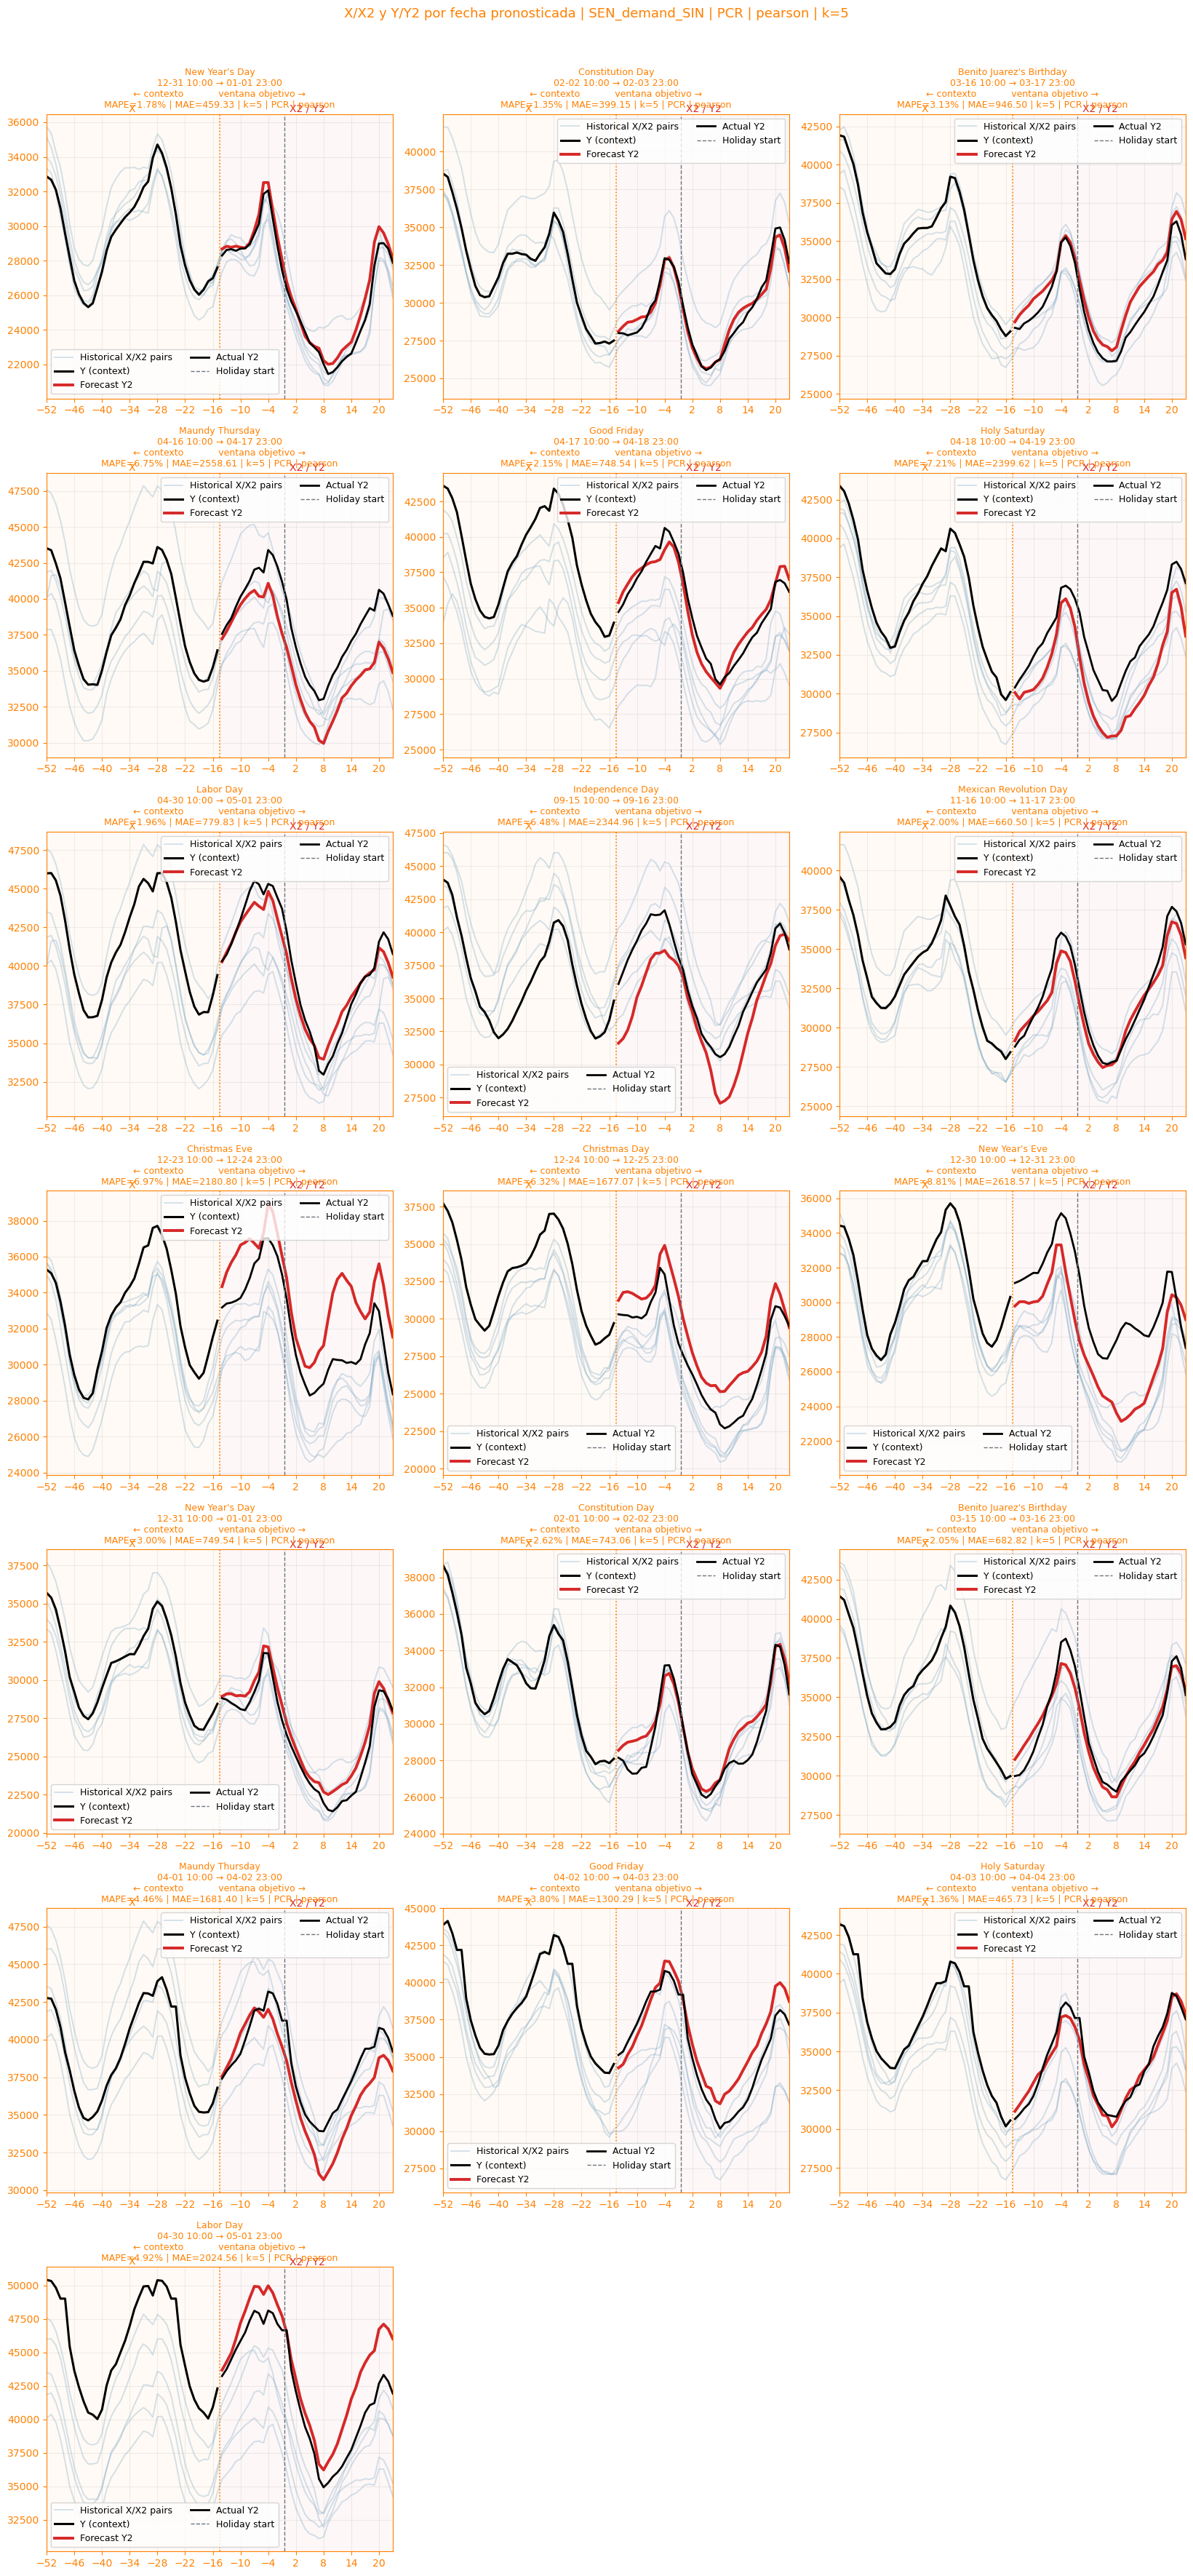

In [19]:
fig_seq, axes_seq = plot_batch_pair_sequences_grid(batch_result_2025)
plt.show()

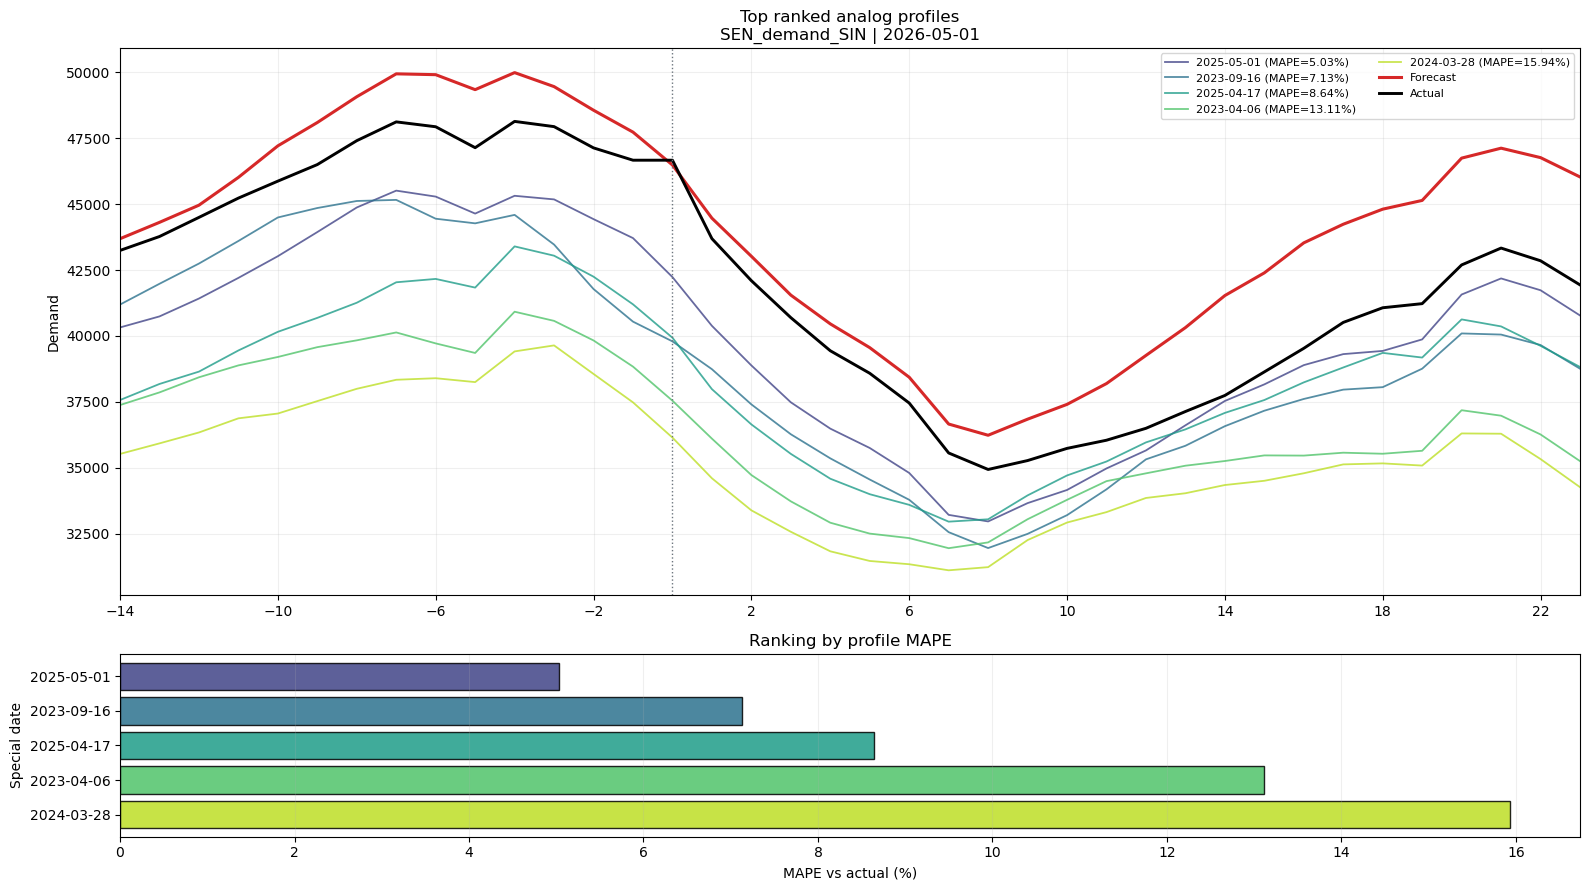

,analog_index,context_date,special_date,label,mape_vs_reference_pct,profile_max,reference_name
0,0,2025-04-28,2025-05-01,holiday,5.028130,45513.36027,actual
1,2,2023-09-13,2023-09-16,holiday,7.134470,45162.08818,actual
2,1,2025-04-14,2025-04-17,holiday,8.638433,43397.69954,actual
3,3,2023-04-03,2023-04-06,holiday,13.112766,40919.16081,actual
4,4,2024-03-25,2024-03-28,holiday,15.937588,39640.55953,actual


In [20]:
ranking_df = build_analog_ranking_table(run)
fig, axes = plot_ranked_analog_profiles(run, top_n=MAX_PLOTTED_ANALOGS)
plt.show()
ranking_df.head(MAX_PLOTTED_ANALOGS)